---
numbering:
  enumerator: "7.%s"
  equation:
    template: "%s"  
---

# Neural networks {#NN}

Neural networks (NNs) are an immensely rich and complicated topic. In this chapter, we introduce the simple ideas and concepts behind the most simple architectures of NNs. For more exhaustive treatments on NN idiosyncracies, we refer to the monographs by @haykin2009neural, @du2013neural and @goodfellow2016deep. The latter is available freely online: www.deeplearningbook.org. For a practical introduction, we recommend the great book of @chollet2017deep.

For starters, we briefly comment on the qualification "neural network". Most experts agree that the term is not very well chosen, as NNs have little to do with how the human brain works (of which we know not that much). This explains why they are often referred to as "artificial neural networks" - we do not use the adjective for notational simplicity. Because we consider it more appropriate, we recall the definition of NNs given by François Chollet: "*chains of differentiable, parameterised geometric functions, trained with gradient descent (with gradients obtained via the chain rule)*". 

Early references of neural networks in finance are @bansal1993no and @eakins1998analyzing. Both have very different goals. In the first one, the authors aim to estimate a **nonlinear form** for the pricing kernel. In the second one, the purpose is to identify and quantify relationships between institutional investments in stocks and the attributes of the firms (an early contribution towards factor investing). An early review (@burrell1997impact) lists financial applications of NNs during the 1990s. More recently, @sezer2019financial, @jiang2020applications and @lim2020time survey the attempts to forecast financial time series with deep-learning models, mainly by computer science scholars.

## The original perceptron

The origins of NNs go back at least to @rosenblatt1958perceptron. Its aim is binary classification. For simplicity, let us assume that the output is $\{0$ = do not invest$\}$ versus $\{1$ = invest$\}$ (e.g., derived from return, negative versus positive). Given the current nomenclature, a perceptron can be defined as an activated linear mapping. The model is the following:

$$f(\mathbf{x})=\left\{ \begin{array}{lll}
1 & \text{if } \mathbf{x}'\mathbf{w}+b >0\\
0  &\text{otherwise}
\end{array}\right.$$

The vector of weights $\mathbf{w}$ scales the variables and the bias $b$ shifts the decision barrier.

![Scheme of a perceptron.](images/NN_percep_scheme.png)

## Multilayer perceptron 

### Introduction and notations

A perceptron can be viewed as a linear model to which is applied a particular function: the Heaviside (step) function. Other choices of functions are naturally possible. In the NN jargon, they are called activation functions. Their purpose is to introduce nonlinearity in otherwise very linear models.

Just like for random forests with trees, the idea behind neural networks is to combine perceptron-like building blocks.

![Simplified scheme of a multi-layer perceptron.](images/nn.png)

![Detailed scheme of a perceptron with 2 intermediate layers.](images/NN_scheme.png)

The process is the following. When entering the network, the data goes though the initial linear mapping:  
$$v_{i,k}^{(1)}=\textbf{x}_i'\textbf{w}^{(1)}_k+b_k^{(1)},  \text{for } l=1, \quad k \in [1,U_1],  $$   
which is then transformed by a non-linear function $f^{1}$.

![Plot of the most common activation functions.](images/activation.png)

### Universal approximation  

One reason neural networks work well is that they are *universal approximators*. Given any bounded continuous function, there exists a one-layer network that can approximate this function up to arbitrary precision.

$$
\mathbb{E}\left[(f(x)-f_n(x))^2 \right]=\underbrace{O\left(\frac{c_f}{n} \right)}_{\text{size of network}}+\ \underbrace{O\left(\frac{nK \log(N)}{N} \right)}_{\text{size of sample}},
$$

### Learning via back-propagation {#backprop}

Just like for tree methods, neural networks are trained by minimizing some loss function subject to some penalization:
$$O=\sum_{i=1}^I \text{loss}(y_i,\tilde{y}_i)+ \text{penalization},$$

The updating of the weights will be performed via gradient descent:

$$
\textbf{W} \leftarrow \textbf{W}-\eta  \frac{\partial D(\tilde{y}_i) }{\partial \textbf{W}}.
$$

![Outline of gradient descent.](images/Newton.png)

![Diagram of back-propagation.](images/backprop.png)

### Further details on classification {#NNclass}

Facing a classification problem, the trick is to use an appropriate activation function at the very end of the network. The most commonly used activation is the so-called *softmax* function:

$$\tilde{\textbf{y}}_i=s(\textbf{x})_i=\frac{e^{x_i}}{\sum_{j=1}^Je^{x_j}}.$$

The cross-entropy is defined as:

$$
\text{CE}(\textbf{y}_i,\tilde{\textbf{y}}_i)=-\sum_{j=1}^J\log(\tilde{y}_{i,j})y_{i,j}.
$$

## How deep we should go and other practical issues {#howdeep}

### Architectural choices

The number of hidden layers in current financial applications rarely exceeds three or four. The number of units per layer $(U_k)$ is often chosen to follow the geometric pyramid rule:
$$U_k\approx \left\lfloor O\left( \frac{I}{O}\right)^{\frac{L+1-k}{L+1}}\right\rfloor.$$

### Penalizations and dropout

$$O=\sum_{i=1}^I \text{loss}(y_i,\tilde{y}_i)+ \sum_{k} \lambda_k||\textbf{W}_k||_1+ \sum_j\delta_j||\textbf{W}_j||_2^2,$$

## Code samples and comments for vanilla MLP

### Regression example

Before we head to the core of the NN, a short stage of data preparation is required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"  # or "torch"

import keras
from keras import layers

In [3]:
from keras import layers, regularizers, constraints, initializers, callbacks

from data_build import generate_data
data_ml, features, features_short, returns, stock_ids, stock_ids_short = generate_data()
features_short =["Div_yld", "EPS", "Size12m", "Mom_LT", "Ocf", "PB", "Vol_LT"]
separation_date = "2017-01-15"

# Data preparation
data_ml_clean = data_ml.dropna()
training_sample = data_ml_clean[data_ml['date'] <= separation_date]
testing_sample = data_ml_clean[data_ml['date'] > separation_date] 
NN_train_features = training_sample[features].values    # Training features
NN_train_labels = training_sample['R1M'].values         # Training labels
NN_test_features = testing_sample[features].values      # Testing features
NN_test_labels = testing_sample['R1M'].values           # Testing labels

In Keras, the training of neural networks is performed through three steps: defining the structure, setting the loss function, and training.

In [4]:
# Define the structure of the network
model = keras.Sequential([
    layers.Dense(units=16, activation='relu', input_shape=(NN_train_features.shape[1],)),
    layers.Dense(units=8, activation='tanh'),
    layers.Dense(units=1)  # No activation means linear activation: f(x) = x
])

In [5]:
# Model specification
model.compile(
    loss='mean_squared_error',
    optimizer='rmsprop',
    metrics=['mean_absolute_error']
)
model.summary()

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         1,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 2,113 (8.25 KB)
 Trainable params: 2,113 (8.25 KB)
 Non-trainable params: 0 (0.00 B)


Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0211 - mean_absolute_error: 0.0922 - val_loss: 0.0101 - val_mean_absolute_error: 0.0726
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0088 - mean_absolute_error: 0.0658 - val_loss: 0.0093 - val_mean_absolute_error: 0.0693
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0086 - mean_absolute_error: 0.0650 - val_loss: 0.0090 - val_mean_absolute_error: 0.0681
Epoch 4/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 897us/step - loss: 0.0084 - mean_absolute_error: 0.0646 - val_loss: 0.0094 - val_mean_absolute_error: 0.0708
Epoch 5/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0083 - mean_absolute_error: 0.0643 - val_loss: 0.0088 - val_mean_absolute_error: 0.0676
Epoch 6/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0083 - mean_absolute_error: 0.0641 - val_loss: 0.0089 - val_mean_absolute_error: 0.0682
Epoch 7/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0082 - mean_absolute_error: 0.0638 -

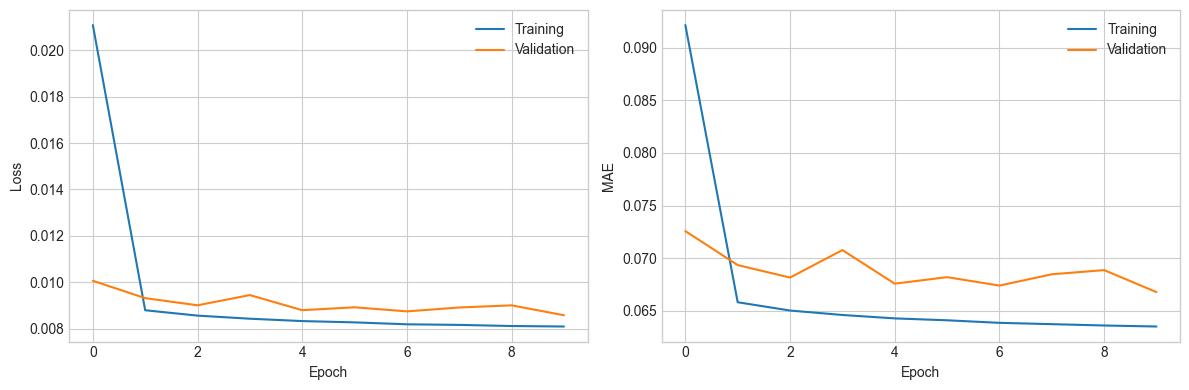

In [6]:
# Train the model
history = model.fit(
    NN_train_features, NN_train_labels,
    epochs=10, batch_size=512,
    validation_data=(NN_test_features, NN_test_labels)
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].plot(history.history['mean_absolute_error'], label='Training')
axes[1].plot(history.history['val_mean_absolute_error'], label='Validation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE'); axes[1].legend()
plt.tight_layout(); plt.show()

In [7]:
# Predictions and hit ratio
predictions = model.predict(NN_test_features).flatten()
hit_ratio = np.mean(predictions * NN_test_labels > 0)
print(f"Hit ratio: {np.round(hit_ratio, 5)}")

2543/2543 ━━━━━━━━━━━━━━━━━━━━ 1s 445us/step
Hit ratio: 0.61639


### Classification example

We pursue our exploration of neural networks with a classification task on the binary label R1M_C.

In [8]:
# One-hot encoding of the labels
NN_train_labels_C = pd.get_dummies(training_sample['R1M_C']).values
NN_test_labels_C = pd.get_dummies(testing_sample['R1M_C']).values

In [9]:
# Define the structure with additional features
model_C = keras.Sequential([
    layers.Dense(units=16, activation='tanh',
                 input_shape=(NN_train_features.shape[1],),
                 kernel_initializer='random_normal',
                 kernel_constraint=constraints.NonNeg()),
    layers.Dropout(rate=0.25),
    layers.Dense(units=8, activation='elu',
                 bias_initializer=initializers.Constant(0.2),
                 kernel_regularizer=regularizers.l2(0.01)),
    layers.Dense(units=2, activation='softmax')
])

In [10]:
# Model specification
model_C.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.005, beta_1=0.9, beta_2=0.95),
    metrics=['categorical_accuracy']
)
model_C.summary()

Model: "sequential_1"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │         1,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 2,122 (8.29 KB)
 Trainable params: 2,122 (8.29 KB)
 Non-trainable params: 0 (0.00 B)


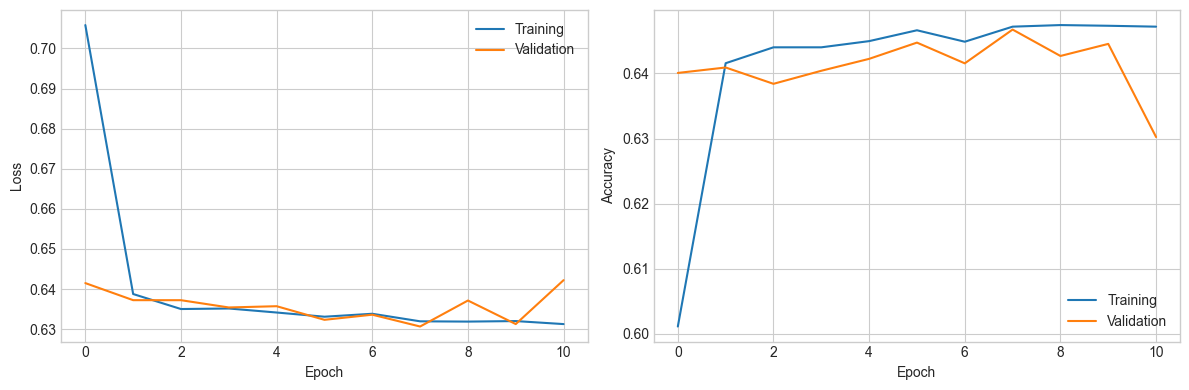

In [11]:
# Train with early stopping
early_stop = callbacks.EarlyStopping(monitor='val_loss', min_delta=0.001, patience=3, verbose=0)

history_C = model_C.fit(
    NN_train_features, NN_train_labels_C,
    epochs=20, batch_size=512,
    validation_data=(NN_test_features, NN_test_labels_C),
    verbose=0, callbacks=[early_stop]
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_C.history['loss'], label='Training')
axes[0].plot(history_C.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].plot(history_C.history['categorical_accuracy'], label='Training')
axes[1].plot(history_C.history['val_categorical_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

### Custom losses {#custloss}

In Keras, it is possible to define user-specified loss functions.

In [14]:
import keras.ops as ops

def custom_loss(y_true, y_pred):
    var_pred = ops.mean((y_pred - ops.mean(y_pred)) * (y_pred - ops.mean(y_pred)))
    cov_term = ops.mean((y_true - ops.mean(y_true)) * (y_pred - ops.mean(y_pred)))
    return var_pred - 5 * cov_term

model_custom = keras.Sequential([
    layers.Dense(units=16, activation='relu', input_shape=(NN_train_features.shape[1],)),
    layers.Dense(units=8, activation='sigmoid'),
    layers.Dense(units=1)
])

model_custom.compile(loss=custom_loss, optimizer='rmsprop', metrics=['mean_absolute_error'])

In [15]:
# Train and evaluate
history_custom = model_custom.fit(
    NN_train_features, NN_train_labels,
    epochs=10, batch_size=512,
    validation_data=(NN_test_features, NN_test_labels)
)

predictions_custom = model_custom.predict(NN_test_features).flatten()
hit_ratio_custom = np.mean(predictions_custom * NN_test_labels > 0)
print(f"Hit ratio: {hit_ratio_custom}")

Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: -0.0055 - mean_absolute_error: 1.2541 - val_loss: -0.0075 - val_mean_absolute_error: 1.3321
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - loss: -0.0087 - mean_absolute_error: 1.3368 - val_loss: -0.0086 - val_mean_absolute_error: 1.3151
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -0.0097 - mean_absolute_error: 1.3361 - val_loss: -0.0094 - val_mean_absolute_error: 1.3264
Epoch 4/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -0.0105 - mean_absolute_error: 1.3515 - val_loss: -0.0101 - val_mean_absolute_error: 1.3951
Epoch 5/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: -0.0112 - mean_absolute_error: 1.3952 - val_loss: -0.0106 - val_mean_absolute_error: 1.4458
Epoch 6/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -0.0117 - mean_absolute_error: 1.4439 - val_loss: -0.0110 - val_mean_absolute_error: 1.4611
Epoch 7/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: -0.0122 - mean_absolute_er

## Recurrent networks {#RNN}

### Presentation

Multilayer perceptrons are feed-forward networks because the data flows from left to right with no looping in between. For some particular tasks with sequential linkages, it might be useful to keep track of what happened with the previous sample.

$$
\begin{align*}
\tilde{y}_i&=f^{(y)}\left(\sum_{j=1}^{U_1}h_{i,j}w^{(y)}_j+b^{(2)}\right) \\
\textbf{h}_{i} &=f^{(h)}\left(\sum_{k=1}^{U_0}x_{i,k}w^{(h,1)}_k+b^{(1)}+ \underbrace{\sum_{k=1}^{U_1}  w^{(h,2)}_{k}h_{i-1,k}}_{\text{memory part}} \right),
\end{align*} 
$$

![Unfolding a recurrent network.](images/RN.png)

The Gated Recurrent Unit (GRU) has the following representation:
$$
\begin{align*}
\tilde{y}_i&=z_i\tilde{y}_{i-1}+ (1-z_i)\tanh \left(\textbf{w}_y'\textbf{x}_i+ b_y+ u_yr_i\tilde{y}_{i-1}\right) \\
z_i &= \text{sig}(\textbf{w}_z'\textbf{x}_i+b_z+u_z\tilde{y}_{i-1}) \\
r_i &= \text{sig}(\textbf{w}_r'\textbf{x}_i+b_r+u_r\tilde{y}_{i-1})
\end{align*} 
$$

### Code and results

In [16]:
# Dedicated dataset for RNN
data_rnn = data_ml[data_ml['fsym_id'].isin(stock_ids_short)]
training_sample_rnn = data_rnn[data_rnn['date'] < separation_date]
testing_sample_rnn = data_rnn[data_rnn['date'] > separation_date]

nb_stocks = len(stock_ids_short)
nb_feats = len(features)
nb_dates_train = len(training_sample_rnn) // nb_stocks
nb_dates_test = len(testing_sample_rnn) // nb_stocks

In [17]:
# Format the data into arrays: (stock, date, feature)
train_features_rnn = training_sample_rnn[features].values.reshape(nb_stocks, nb_dates_train, nb_feats)
test_features_rnn = testing_sample_rnn[features].values.reshape(nb_stocks, nb_dates_test, nb_feats)
train_labels_rnn = training_sample_rnn['R1M'].values.reshape(nb_stocks, nb_dates_train, 1)
test_labels_rnn = testing_sample_rnn['R1M'].values.reshape(nb_stocks, nb_dates_test, 1)

In [ ]:
# Define the RNN model
model_RNN = keras.Sequential([
    layers.GRU(units=16, 
               #input_batch_size=nb_stocks,
               #input_shape=(nb_dates_train, nb_feats),
               activation='tanh', return_sequences=True),
    layers.Dense(units=1)
])

model_RNN.compile(loss='mean_squared_error', optimizer='rmsprop', metrics=['mean_absolute_error'])

In [22]:
# Train the RNN model
history_RNN = model_RNN.fit(
    train_features_rnn, train_labels_rnn,
    epochs=10, batch_size=nb_stocks, verbose=0
)

In [26]:
pred_rnn = model_RNN.predict(test_features_rnn, batch_size=nb_stocks)
hit_ratio_rnn = np.mean(pred_rnn.flatten() * test_labels_rnn.flatten() > 0)
print(f"Hit ratio: {hit_ratio_rnn}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Hit ratio: 0.48850827111696676


## Other common architectures

### Generative adversarial networks {#generative-aversarial-networks}

GANs consist in two neural networks: the first one tries to learn and the second one tries to fool the first. $D$ and $G$ play the following minimax game:
$$
\underset{G}{\min} \ \underset{D}{\max} \ \left\{ \mathbb{E}[\log(D(\textbf{x}))]+\mathbb{E}[\log(1-D(G(\textbf{z})))] \right\}.
$$

### Autoencoders {#autoencoders}

AEs are a family of neural networks where the label is equal to the input:
$$\begin{array}{ccccccccc}
\textbf{x} & &\overset{E}{\longrightarrow} && \textbf{z} && \overset{D}{\longrightarrow} && \textbf{x}' \\
\text{input} && \text{encoder} && \text{code} && \text{decoder} && \text{modified input}
\end{array}$$

### A word on convolutional networks {#CNN}

CNNs allow to progressively reduce the dimension of a large dataset by keeping local information. The output values are given by:
$$o_{i,k}=\sum_{j=1}^J\sum_{l=1}^Lw_{j,l}x_{i+j-1,k+l-1}.$$

![Scheme of a convolutional unit.](images/cnn_scheme.png)

![Scheme of pooling units.](images/cnn_pooling.png)

## Coding exercises

1. Code the autoencoder model described in @gu2019autoencoder using the functional API.

2. Demonstrate the universal approximation of simple NNs by approximating sin(x) over [0,6] with 16 and then 128 units.